# Week 1: ML Fundamentals & Basic Supervised Models 

### Concepts

- What is ML? Types of ML: Supervised, Unsupervised
    - Algorithms that improve on some task with
    experience.
    - Supervised Learning: uses labeled datasets, each input paired with an output and we learn the relation between them.
        1. Classification: assigns test data into categories (discrete output) 
        e.g. Linear classifiers, support vector machines, decision trees and random forest.
        2. Regression: uses an algorithm to understand the relationship between dependent and independent variables (continuous output) e.g. Linear regression, Polynomial regression, and Ridge regression.
    - Unsupervised Learning: uses unlabeled data, learns hidden pattern and structure within dataset.
        1. Clustering: data mining technique for grouping unlabeled data based on their similarities or differences.
        2. Association: uses different rules to find relationships between variables in a given data set.
        3. Dimensionality reduction: it is used when the number of features (or dimensions) in a given data set is too high. It reduces noise and redundancy in the data (Data compression).
    
    Reference: 
    1. https://www.geeksforgeeks.org/machine-learning/difference-between-supervised-and-unsupervised-learning/
    2. https://www.ibm.com/think/topics/supervised-vs-unsupervised-learning

- ML Workflow: Problem definition → Data Collection → Preprocessing → Model 
Training → Evaluation → Deployment
    - Problem Definition: identify and define problem statement.
    - Data Collection: features are Revelent, Quality, Quantity, Diversity.
    - Preprocessing:
        1. Data Cleaning: address issues as missing values, outliers and inconsistencies in data.
        2. Data Preprocessing: Transform the data into a suitable format for machine learning:
        - Feature scaling (Normalization/Standardization)
        - Encoding categorical variables
        - Feature selection
        - Data splitting (training and testing sets)
    Reference: https://www.geeksforgeeks.org/machine-learning/machine-learning-lifecycle/

- Bias-Variance Tradeoff
    - Bias: Error caused by overly simple assumptions in the model, which may lead to underfitting.
    - Variance: Error caused by the model being too sensitive to training data, which may lead to overfitting.
    - It describes the balance between a simplicity and complexity of a model.
    - Simple model -> high bias + low variance (underfitting)
    - Complex model -> low bias + high variance (overfitting)
    
    - Methods to measure bias-variance tradeoff:
        1. Cross Validation
        2. Regularization: L1 (Lasso) and L2 (Ridge)
        3. Feature Selection
        4. Ensemble Methods
        5. Adjusting Model Complexity
        
    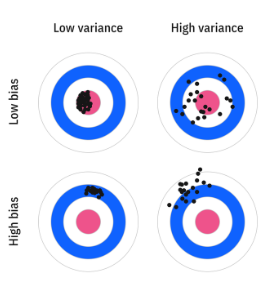
    
    Reference: https://www.geeksforgeeks.org/machine-learning/ml-bias-variance-trade-off/
- Exploratory Data Analysis 
    - Exploratory Data Analysis (EDA) is an important step in data analysis where we explore, summarize, and visualize data to understand its structure, detect patterns, identify anomalies, test assumptions, and check relationships between variables before applying any machine learning or statistical models.
    - types of EDA: univariate, bivariate & multivariate.

    Reference: https://www.geeksforgeeks.org/data-analysis/what-is-exploratory-data-analysis/

- Gradient Descents (SGD, Batch, etc.)
    - It's an algorithm used to minimize error by updating parameters as model trains itself.

- Overfitting vs Underfitting: overfitting is when model starts memorizing the training data and starts failing on new data, however, underfitting is when model is too simple and fails both on training data and test data.
- Evaluation Metrics: Accuracy, Precision, Recall, F1-score, MSE, R²  
    1. Accuracy: (TP+TN)/(TP+TN+FP+FN)
        - Measures overall correctness of the model.
        - fails when there is class imbalance
    2. Precision: TP/(TP+FP)
        - Measures how many predicted positives are actually positive.
    3. Recall: TP/(TP+FN)
        - Measures how many actual positives the model successfully finds.
    4. F-1 Score: 
        - F1 = 2 × (Precision × Recall) / (Precision + Recall)
        - Combines Precision and Recall into a single metric.
        - A model receives a high F1 score only when both Precision and Recall are high.
        - Useful for imbalanced datasets where Accuracy may be misleading.
    5. Mean Square Error: summation of (predicted output - actual output)^2 / n
    6. R^2 score represents the proportion of the variance in the dependent variable that is predictable from the independent variables.
    - R² = 1 : Perfect predictions.
    - R² = 0 : Model performs no better than predicting the mean.
    - R² < 0 : Model performs worse than simply predicting the mean.
    - Higher R² values indicate a better fit.
    - Commonly used to evaluate regression models.

### Hands-On 
- Setup: Jupyter Notebook, pandas, numpy, seaborn, scikit-learn 
- Dataset Exploration: Iris, Boston Housing 
- Linear Regression 
- Logistic Regression

### Checkpoint Evaluation 
- Explain bias-variance tradeoff & evaluation metrics in your own words 
- Implement and compare Linear and Logistic Regression (code + visualization) 


## Linear Regression
        - Correlation Heatmap
        - Select X and y
        - Handle multicollinearity
        - Train-Test Split
        - Feature Scaling
        - Train Linear Regression
        - Predict
        - Evaluate (MSE, RMSE, R²)

In [15]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
from pandas import read_csv

- Dataset for Linear Regression is Boston Housing
- Reference: https://www.kaggle.com/code/prasadperera/the-boston-housing-dataset

In [37]:
#loading dataset
df = pd.read_csv('housing.csv')

#column name not defined in csv file, imported it from kaggle web
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)
print(data.head(5))

#dimension of the dataset
print(np.shape(data))

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  
(506, 14)


### EDA
- Deep Red: Indicates a high positive correlation.
- Deep Blue: Indicates a high negative correlation.
- Pale / White / Light Gray: Indicates little to no correlation (numbers near 0).

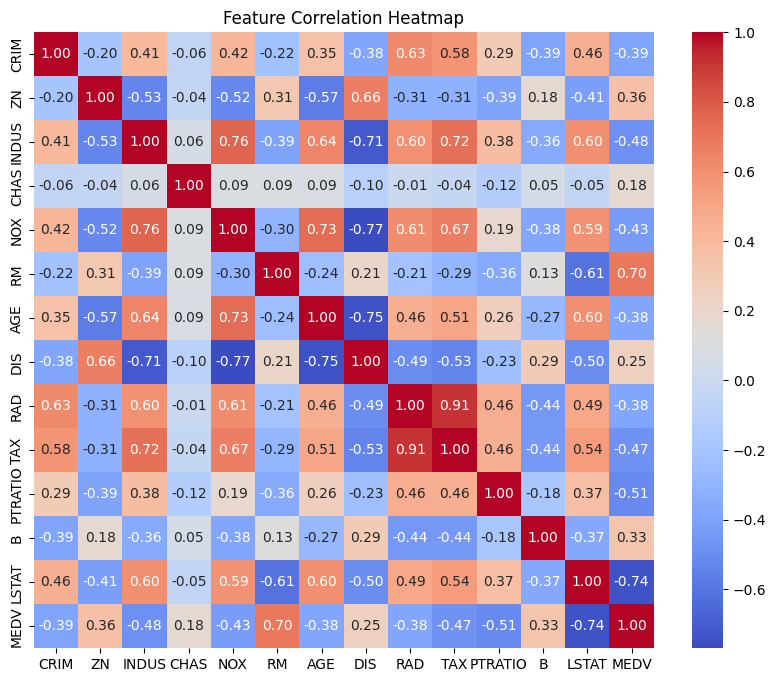

In [38]:
#checking correlation
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

### Target Variable
- My question: how to select a target variable from a dataset?
- Whatever u are trying to predict is the target variable.

- Goal of Boston Housing Dataset: "Predict the price of a house based on various features."
    - X = [CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT]
    - y = MEDV

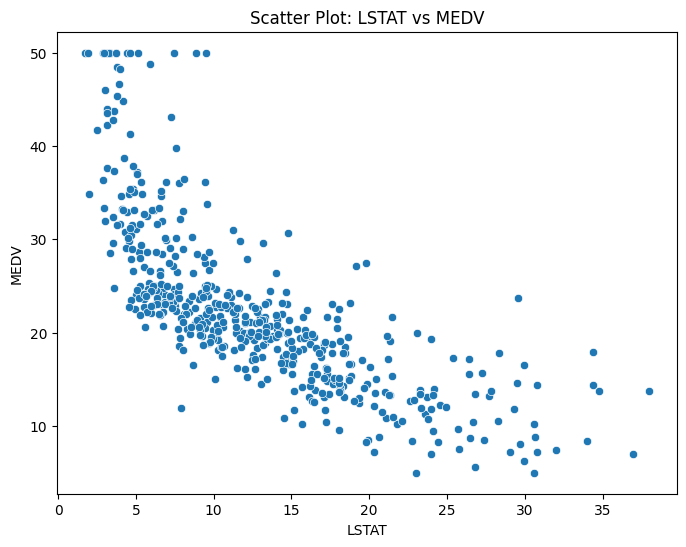

In [39]:
# Dynamically grabs the index of the very last column (which will be 13)
target_col = data.columns[-1]

y = data[target_col]
x = data.drop(columns=[target_col])

#find the highest correlation
correlations = data.corr(numeric_only=True)[target_col].drop(target_col).abs() #taking absolute to find the strongest relationship, regardless of whether it's positive or negative.
top_feature = correlations.idxmax()

#create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data[top_feature], y=data[target_col])
plt.title(f"Scatter Plot: {top_feature} vs {target_col}")
plt.xlabel(top_feature)
plt.ylabel(target_col)
plt.show()

### Identifying the type of correlation.
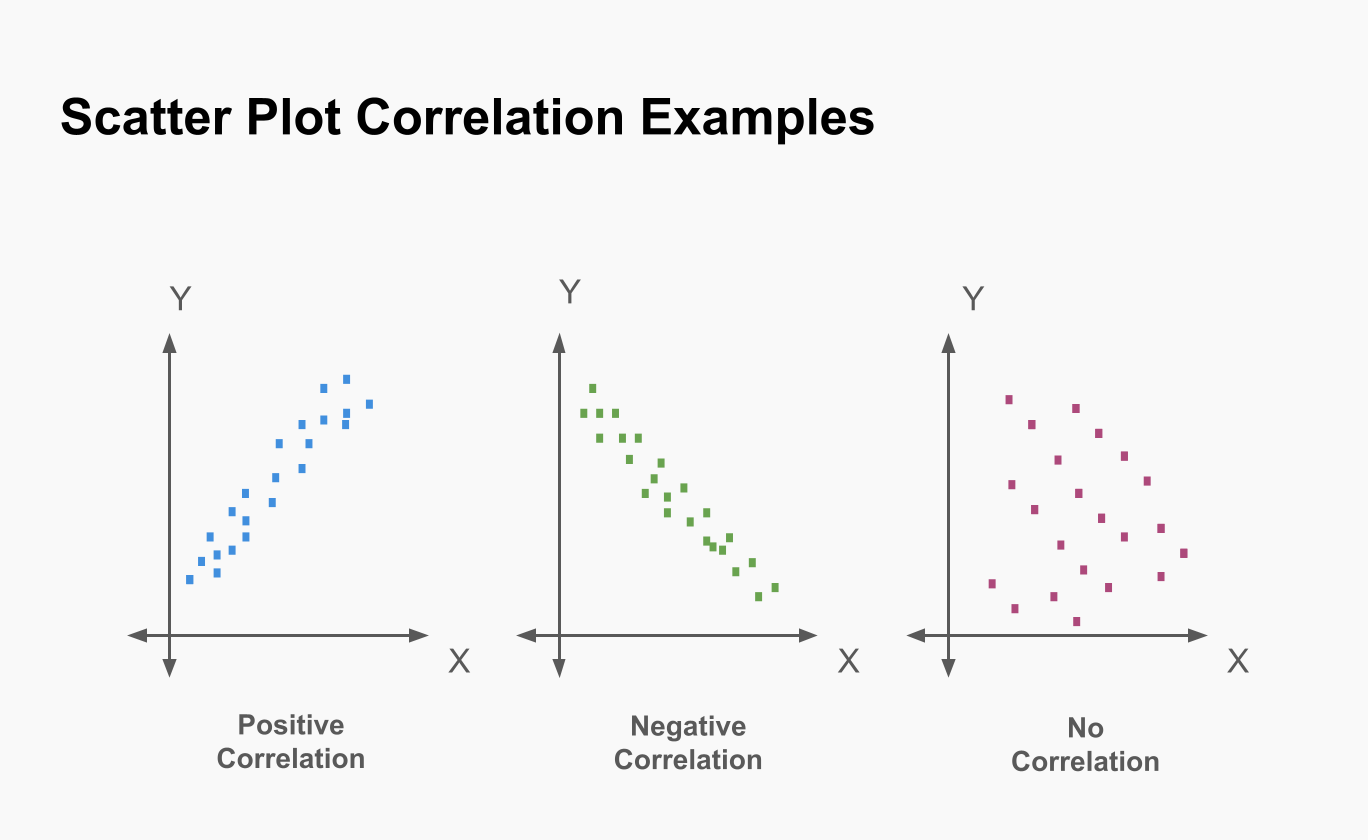

- LSTAT & MEDV has negative correlation
    - LSTAT = Percentage of lower-status population.
    - MEDV = Median house value.

- what do we get outta this information?
    - As LSTAT increases, MEDV tends to decrease.
    - negative relation so β₁ < 0

*experiment:*
Applying linear regression without dropping a feature.

In [40]:
#dropping this feature cuz RAD and TAX are extremely correlated (0.91).
x = x.drop('RAD', axis=1)

### Train-Test Split

In [41]:
#20% test data
#random_state=42 -> shuffles data

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

### Feature Scaling

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### Train Model
- Reference: https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Prediction

In [44]:
y_pred = model.predict(x_test)

### Evaluation

In [45]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 5.144992285668726
R² Score: 0.6390347738951406


### Understand the evaluation
- Root Mean Squared Error:
    - RMSE = 0      → Perfect model
    - RMSE = 2      → Very good
    - RMSE = 5      → Decent
    - RMSE = 15     → Poor
- R^2 Score:
    - 1 -> Perfect Predictions
    - 0.9 -> Excellent
    - 0.8 -> Very good
    - 0.6 - 0.7 -> Good
    - 0.4 -> Weak
    - 0 -> 
    - -ve -> Very Poor Model

Source: Chatgpt :)

- Without dropping a feature

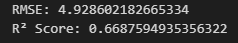

- After dropping a feature

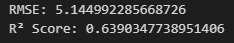

- Conclusion: A highly correlated feature was removed to reduce multicollinearity. However, the model's RMSE increased from 4.93 to 5.14, while the R² score decreased from 0.669 to 0.639. This indicates that the removed feature contained useful predictive information, and the original model performed better. Reducing multicollinearity does not necessarily improve a model's predictive performance. In this case, keeping all features resulted in better predictions.